# Store Performance and Market Structure
### Iowa Liquor Sales — Chain Market Share, Store Productivity, and Channel Mix

## Business Question

Iowa liquor sales flow through hundreds of stores across multiple retail formats — from large grocery chains to warehouse clubs to independent corner stores. Understanding how sales concentrate across chains and how store formats differ in productivity helps answer:

- Which chains dominate the market, and how fragmented is the long tail?
- Do larger chains outperform smaller ones in per-store productivity, or does format matter more than footprint?
- How does the retail channel (grocery vs. warehouse vs. liquor store) shape purchasing volume and store efficiency?

## Analytical Approach

Sales are aggregated over a trailing window anchored to a configurable month. Chains are ranked by total sales and the top N are named explicitly; all others roll into **Other**. Store productivity is measured as **average sales per store** — a metric that normalizes for footprint size and reveals format-level efficiency differences.

Store channels follow Nielsen/Circana retail classifications (Grocery, Warehouse/Club, Liquor Store, Drug, Convenience, Other) assigned in `dim_store`.

## System Notes

- Source: `fct_store_daily_sales` joined to `dim_store`
- Models built with dbt; data loaded into Snowflake via the ingestion pipeline
- All SQL in `analysis/sql/`; chart functions in `analysis/python/charts.py`

In [1]:
from pathlib import Path
import importlib
import sys
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "dbt_project.yml").exists()), cwd)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from analysis.python import notebook_helpers as nh
from analysis.python import charts
importlib.reload(charts)

<module 'analysis.python.charts' from '/Users/joelam/docs/Data_Science/planning_os/analysis/python/charts.py'>

In [2]:
root = nh.get_project_root(project_root)
engine = nh.get_engine_from_env()

print(f'Project root: {root}')

Project root: /Users/joelam/docs/Data_Science/planning_os


In [3]:
params = {
    # Anchor date for the trailing window. Use YYYY-MM-01 format.
    'month_start': '2025-12-01',

    # Number of trailing weeks to include.
    'trailing_weeks': 52,

    # Number of named chains to break out; all others become 'Other'.
    'top_n_chains': 10,
}

params

{'month_start': '2025-12-01', 'trailing_weeks': 52, 'top_n_chains': 10}

## Chain Market Share

The Iowa liquor market is served by a mix of large grocery chains, warehouse clubs, and a long tail of independent and smaller regional stores. This chart shows how total sales concentrate across the top chains — and how much the long tail collectively represents.

Chains are ranked by total sales over the trailing window. The top `top_n_chains` are named; all others roll into **Other**.

In [4]:
chain_sql_template = nh.read_sql(root, 'analysis/sql/store_chain_performance.sql')
chain_sql = nh.render_sql(
    chain_sql_template,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
    top_n_chains=params['top_n_chains'],
)

df_chain = nh.run_sql(engine, chain_sql)
df_chain.head()

,chain_group,total_sales,store_count,avg_sales_per_store,pct_of_market
0,Small/Ind Chain,1.658302e+08,984,168526.667012,0.389440
1,HY-VEE,1.289288e+08,192,671504.126250,0.302780
2,CASEY'S,3.468357e+07,551,62946.588929,0.081452
3,FAREWAY,2.627845e+07,121,217177.305289,0.061713
4,WALMART,2.129237e+07,60,354872.792167,0.050004


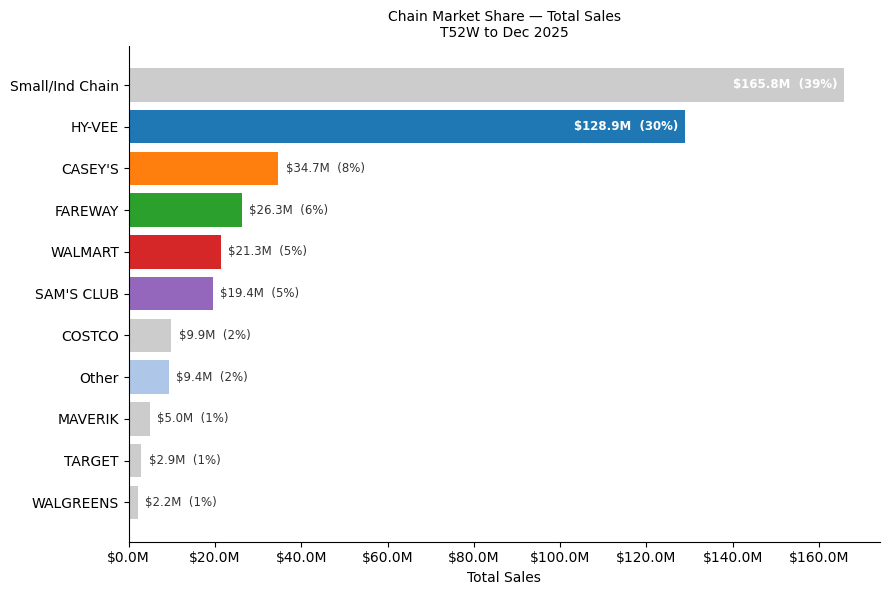

In [5]:
charts.plot_chain_market_share(
    df_chain,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

### Findings: Chain Market Share

**The independent and small chain segment leads the market — 
and that's the most important finding in this chart.**

Small and independent stores collectively account for 
$165.8M in sales — 39% of the total market — across 984 
locations. That's more than Hy-Vee, the largest named chain, 
by $37M. The long tail isn't a rounding error. It's the 
single largest segment in the Iowa liquor market by 
total sales.

**Hy-Vee is the dominant named chain at 30% market share.**
$128.9M across 192 locations. As Iowa's primary regional 
grocery chain, Hy-Vee's liquor department generates more 
volume than any other single brand in the state — and its 
footprint is deeply embedded in the state's grocery 
infrastructure.

**The convenience channel has significant collective scale.**
Casey's at $34.7M across 551 locations is the third largest 
named chain by total sales — but that volume is spread thin 
across a massive convenience store network. The per-store 
story is very different, as the productivity chart reveals.

**Warehouse clubs are invisible on total sales but dominant 
on productivity.**
Sam's Club at $19.4M and Costco at $9.9M look modest in 
this view — 5% and 2% of market share respectively. That 
framing is misleading. With 9 and 4 locations respectively, 
their per-store contribution is extraordinary. Total sales 
understates their commercial importance.

**The long tail beyond the top 10 is real but fragmented.**
Other at $9.4M across 156 stores — regional banners, 
specialty retailers, and mid-sized independents that don't 
fit a named chain. Meaningful in aggregate, difficult to 
serve efficiently at scale.

## Store Productivity

Total sales reflect footprint as much as efficiency. **Average sales per store** normalizes for chain size and reveals how much revenue each outlet generates on a per-location basis.

Warehouse clubs (e.g., Sam's Club) tend to dominate this metric due to bulk purchasing and large basket sizes. Convenience-oriented chains serve a different shopper mission and will naturally show lower per-store productivity — a difference in format, not execution.

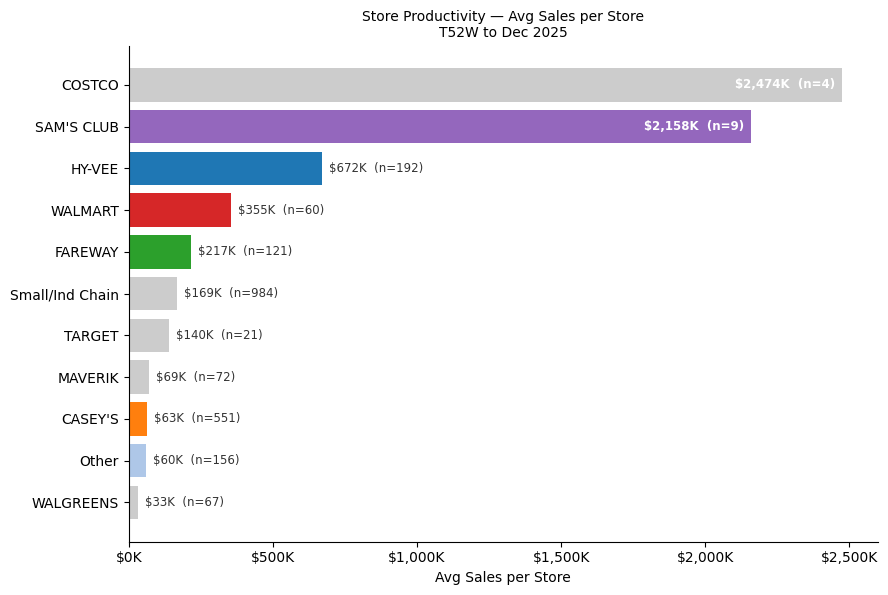

In [6]:
charts.plot_store_productivity(
    df_chain,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

### Findings: Store Productivity

**The productivity ranking tells a completely different story 
than the sales ranking — and the gap is dramatic.**

**Warehouse clubs operate in a different commercial universe.**
Costco at $2,474K per store (4 locations) and Sam's Club at 
$2,158K per store (9 locations) sit in a category of their 
own — nearly 4x Hy-Vee's productivity and 35x Casey's. 
These are not incremental volume contributors. They are 
the most commercially efficient liquor outlets in the 
Iowa market by a significant margin.

Bulk purchasing behavior, large basket sizes, and a 
destination shopping mission produce per-store economics 
that no other format can match. A single Costco location 
generates as much liquor revenue as roughly 39 Casey's stores.

**Hy-Vee leads the grocery format at $672K per store.**
With 192 locations, Hy-Vee is both the largest named chain 
by total sales and the most productive grocery chain by 
per-store average. The combination of scale and productivity 
is what makes Hy-Vee the institutional anchor of the 
Iowa liquor market.

**Walmart outperforms its total sales ranking on productivity.**
$355K per store across 60 locations. Walmart's Iowa liquor 
presence is selectively deployed — not every location carries 
liquor — which means the stores that do are high-performing 
relative to the chain's broader footprint.

**Casey's and Maverik reflect the convenience format ceiling.**
Casey's at $63K per store (551 locations) and Maverik at 
$69K per store (72 locations) are performing as expected 
for convenience formats — impulse purchase, top-up buying, 
limited selection. These chains are not underperforming. 
They are operating a fundamentally different business.

**Walgreens is the lowest productivity named chain at $33K.**
67 locations generating $33K per store — reflecting the 
drug store format's limited liquor assortment and 
incidental rather than destination purchasing behavior.

**The key insight:** Benchmarking chains against each other 
on productivity without accounting for format produces 
systematically misleading conclusions. The relevant 
comparison is Costco vs. Sam's Club, Hy-Vee vs. Fareway, 
Casey's vs. Maverik — not Costco vs. Casey's.

## Store Channel Mix

Retail formats serve distinct shopper missions. A grocery trip looks different from a warehouse run or a specialty liquor store visit — and those differences show up in both total sales and per-store productivity.

Store channels are classified using Nielsen/Circana-aligned taxonomy defined in `dim_store`. This view shows how Iowa's liquor volume distributes across formats and where per-outlet productivity is highest.

In [7]:
channel_sql_template = nh.read_sql(root, 'analysis/sql/store_channel_performance.sql')
channel_sql = nh.render_sql(
    channel_sql_template,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

df_channel = nh.run_sql(engine, channel_sql)
df_channel.head()

,store_channel,total_sales,store_count,avg_sales_per_store,pct_of_market
0,Grocery,1.850588e+08,564,3.281184e+05,0.434597
1,Liquor Store,9.932282e+07,259,3.834858e+05,0.233252
2,Convenience/Gas,6.801949e+07,1031,6.597429e+04,0.159739
3,Warehouse/Club,2.931829e+07,13,2.255253e+06,0.068852
4,Mass Merchandise,2.423326e+07,81,2.991761e+05,0.056910


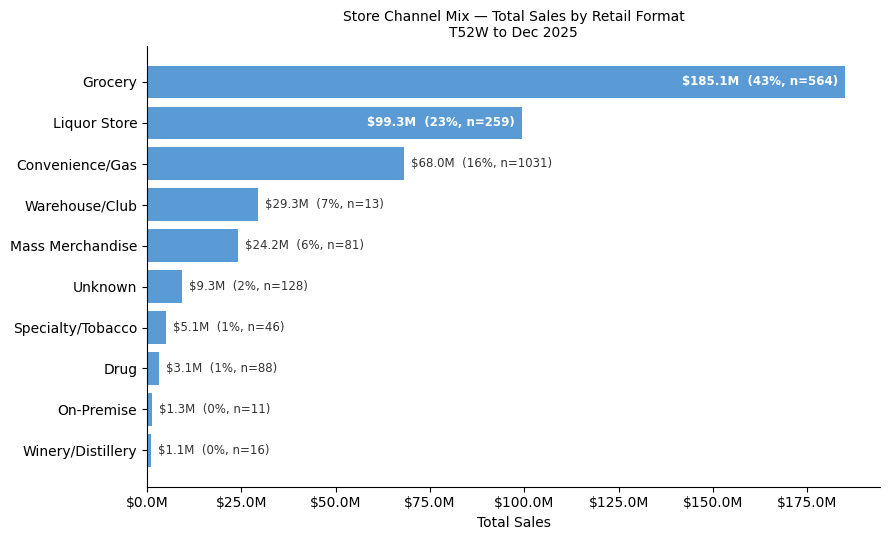

In [8]:
charts.plot_channel_mix(
    df_channel,
    month_start=params['month_start'],
    trailing_weeks=params['trailing_weeks'],
)

### Findings: Store Channel Mix

**Five formats account for 98% of market volume. 
Each serves a structurally different shopper mission.**

**Grocery leads total volume by a wide margin.**
$185.1M and 43% of market sales across 564 stores. 
Grocery's dominance reflects footprint — Hy-Vee anchors 
this channel — combined with the destination shopping 
mission that drives large basket sizes and frequent visits.

**Liquor stores punch above their weight.**
259 stores generating $99.3M — 23% of market volume 
and approximately $383K per store. Dedicated liquor stores 
attract destination shoppers with higher purchase intent 
and broader selection, which drives larger baskets despite 
smaller physical footprints than grocery.

**Convenience/Gas has the largest store count and the 
lowest productivity.**
1,031 locations generating $68M — approximately $66K 
per store. The convenience format serves a high-frequency, 
low-basket mission. High location count reflects geographic 
distribution strategy, not commercial dominance. Casey's, 
Maverik, and similar chains anchor this channel.

**Warehouse/Club is the most productive format in the market.**
13 stores generating $29.3M — approximately $2.25M per 
store. Costco and Sam's Club account for essentially all 
of this channel. Small by store count, extraordinary by 
per-store productivity. The commercial efficiency of the 
warehouse format is visible here in aggregate form — 
and in granular form in the productivity chart above.

**Mass Merchandise at 6% reflects selective deployment.**
$24.2M across 81 stores — primarily Walmart and Target 
locations that carry liquor. Not all mass merchandise 
locations in Iowa have liquor departments, which means 
this channel's productivity reflects a self-selected 
high-performing subset.

**The remaining formats are structurally present but 
commercially marginal.**
Drug ($3.1M), Specialty/Tobacco ($5.1M), On-Premise 
($1.3M), and Winery/Distillery ($1.1M) collectively 
represent under 3% of market volume. Each serves a 
specific and limited purchasing occasion that doesn't 
scale to meaningful market share.

### Implication

Format determines productivity more than chain identity — 
and format should determine planning strategy.

Replenishment cadence, assortment depth, and promotional 
allocation should be calibrated to format first, chain 
second. A warehouse club location requires a completely 
different replenishment model than a convenience store — 
different reorder triggers, different safety stock logic, 
different assortment depth.

A planning system that treats all stores equally would 
systematically over-serve low-productivity formats and 
under-serve high-productivity ones. The channel mix 
analysis is the foundation for building format-aware 
planning logic — which is exactly what a well-designed 
data system enables.

## Final Takeaways

The Iowa liquor market looks simple from the outside — 
a handful of chains selling spirits through retail stores. 
The data reveals something more structurally interesting.

**The independent segment is the market's largest single 
player — and the most overlooked.**
Small and independent stores collectively generate $165.8M 
in sales across 984 locations — more than Hy-Vee, more than 
any named chain, and 39% of the total market. The long tail 
is not noise. It is the foundation of the market's volume.

**Warehouse clubs operate in a different commercial universe.**
Costco at $2,474K per store and Sam's Club at $2,158K per 
store are not incremental contributors to the Iowa liquor 
market. They are its most productive outlets by a factor 
of 3-4x over the next tier. A single Costco generates as 
much liquor revenue as approximately 39 Casey's stores. 
Format differences of this magnitude require format-aware 
planning — not a uniform approach applied across a 
heterogeneous store base.

**Productivity varies more by format than by chain.**
The productivity ranking bears almost no resemblance to 
the sales ranking. Chains that lead on total volume — 
Small/Ind Chain, Casey's — sit at the bottom of the 
productivity chart. Chains that are nearly invisible on 
total sales — Costco, Sam's Club — sit at the top. 
Understanding which metric matters for which decision 
is the analytical competency that separates useful market 
structure analysis from misleading benchmarking.

**Channel mix reflects shopper mission — and mission 
determines planning logic.**
Grocery leads on volume because of footprint and frequency. 
Warehouse clubs lead on productivity because of basket size 
and bulk purchasing. Liquor stores outperform grocery on 
a per-store basis because of destination purchase intent. 
Convenience leads on location count and trails on everything 
else. These are different businesses serving different 
occasions — and a planning system that treats them the same 
will systematically produce the wrong recommendations.

**The practical implication:**
Format-aware planning — calibrating replenishment cadence, 
assortment depth, and promotional strategy to store format 
rather than chain name — is the highest-leverage operational 
insight this analysis supports. That requires a data system 
that can surface format-level dynamics reliably and 
consistently. That is what this system is built to enable.